# Notebook 2: Preprocessing

This notebook prepares the expression matrix for downstream analysis by selecting usable cells and genes, normalizing for sequencing depth, and applying a log transformation.

* `adata.X` contains integer-valued, count-like expression data, with row sums matching `obs['ncounts']`. A copy is stored before normalization for reproducibility.
* 16 cells with missing or unusable `perturbation` labels are removed because they cannot be assigned to a perturbation group.
* The status of `62(mod)_pBA581` as a negative control and the meaning of `nperts` remain unresolved and are not used in preprocessing decisions.


## Setup

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Loading the dataset

In [2]:
data_path = "F:/scRNA/AdamsonWeissman2016_GSM2406675_10X001.h5ad"
adata = sc.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 5768 × 35635
    obs: 'perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts'
    var: 'ensembl_id', 'ncounts', 'ncells'

## Step 1: Remove cells with no usable perturbation label


In [3]:
is_missing = adata.obs["perturbation"].isna()
is_ambiguous_mark = adata.obs["perturbation"] == "*"
is_ambiguous = is_missing | is_ambiguous_mark

print("cells before removing ambiguous labels:", adata.n_obs)
adata = adata[~is_ambiguous, :].copy()
print("cells after removing ambiguous labels:", adata.n_obs)

cells before removing ambiguous labels: 5768
cells after removing ambiguous labels: 5752


## Step 2: Cell-level quality filtering


In [4]:
min_genes_per_cell = 200

genes_per_cell = np.asarray((adata.X > 0).sum(axis=1)).flatten()
keep_cell = genes_per_cell >= min_genes_per_cell

print("cells below the", min_genes_per_cell, "gene threshold:", (~keep_cell).sum())
print("cells before this filter:", adata.n_obs)
adata = adata[keep_cell, :].copy()
print("cells after this filter:", adata.n_obs)

cells below the 200 gene threshold: 0
cells before this filter: 5752
cells after this filter: 5752


## Step 3: Gene-level filtering


In [5]:
min_cells_per_gene = 3

cells_per_gene = np.asarray((adata.X > 0).sum(axis=0)).flatten()
keep_gene = cells_per_gene >= min_cells_per_gene

print("genes below the", min_cells_per_gene, "cell threshold:", (~keep_gene).sum())
print("genes before this filter:", adata.n_vars)
adata = adata[:, keep_gene].copy()
print("genes after this filter:", adata.n_vars)

genes below the 3 cell threshold: 20945
genes before this filter: 35635
genes after this filter: 14690


## Recomputing per-cell and per-gene summaries


In [6]:
adata.obs["ncounts"] = np.asarray(adata.X.sum(axis=1)).flatten()
adata.obs["ngenes"] = np.asarray((adata.X > 0).sum(axis=1)).flatten()
adata.var["ncounts"] = np.asarray(adata.X.sum(axis=0)).flatten()
adata.var["ncells"] = np.asarray((adata.X > 0).sum(axis=0)).flatten()

adata.obs[["ncounts", "ngenes"]].describe()

,ncounts,ngenes
count,5752.000000,5752.000000
mean,10163.275391,2556.472531
std,3241.585449,462.878472
min,1975.000000,520.000000
25%,8253.750000,2331.000000
50%,9965.000000,2579.000000
75%,11934.750000,2830.000000
max,28608.000000,4402.000000


## Keeping the raw counts


In [7]:
adata.layers["counts"] = adata.X.copy()

## Step 4: Normalization


In [8]:
target_sum = 10000.0

cell_totals = np.asarray(adata.X.sum(axis=1)).flatten()
scaling_factors = target_sum / cell_totals

scaling_matrix = sp.diags(scaling_factors)
adata.X = scaling_matrix @ adata.X

new_totals = np.asarray(adata.X.sum(axis=1)).flatten()
print("min total after normalization:", new_totals.min())
print("max total after normalization:", new_totals.max())

min total after normalization: 9999.998
max total after normalization: 10000.002


## Step 5: Log transformation


In [9]:
adata.X = adata.X.tocsr()
adata.X.data = np.log1p(adata.X.data)

print("max value after log1p:", adata.X.data.max())
print("min non-zero value after log1p:", adata.X.data.min())

max value after log1p: 6.954742
min non-zero value after log1p: 0.29977313


## Step 6: Flagging highly variable genes


In [10]:
n_top_genes = 2000
min_cells_for_hvg = max(10, int(0.01 * adata.n_obs))

X = adata.X.tocsc()

gene_mean = np.asarray(X.mean(axis=0)).flatten()
gene_mean_sq = np.asarray(X.multiply(X).mean(axis=0)).flatten()
gene_var = gene_mean_sq - gene_mean ** 2

eps = 1e-8
dispersion = gene_var / (gene_mean + eps)

adata.var["mean_log_expression"] = gene_mean
adata.var["variance_log_expression"] = gene_var
adata.var["dispersion"] = dispersion

eligible_for_hvg = adata.var["ncells"] >= min_cells_for_hvg
print("genes eligible for HVG ranking (detected in at least", min_cells_for_hvg, "cells):",
      eligible_for_hvg.sum(), "of", adata.n_vars)

hvg_rank = adata.var.loc[eligible_for_hvg, "dispersion"].rank(ascending=False)
highly_variable = pd.Series(False, index=adata.var.index)
highly_variable.loc[eligible_for_hvg] = hvg_rank <= n_top_genes
adata.var["highly_variable"] = highly_variable

print("number of genes flagged as highly variable:", adata.var["highly_variable"].sum())
print("median cells-detected among highly variable genes:",
      adata.var.loc[adata.var["highly_variable"], "ncells"].median())
print("median cells-detected among all genes:", adata.var["ncells"].median())

genes eligible for HVG ranking (detected in at least 57 cells): 10636 of 14690
number of genes flagged as highly variable: 2000
median cells-detected among highly variable genes: 158.0
median cells-detected among all genes: 335.0


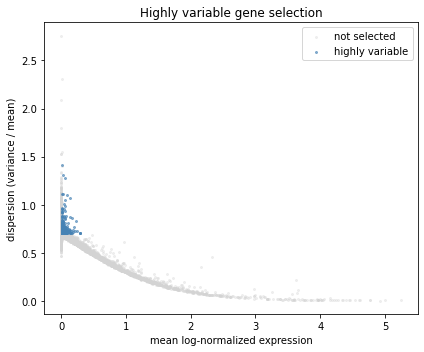

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

not_hvg = ~adata.var["highly_variable"]
ax.scatter(adata.var.loc[not_hvg, "mean_log_expression"],
           adata.var.loc[not_hvg, "dispersion"],
           s=4, alpha=0.3, color="lightgray", label="not selected")
ax.scatter(adata.var.loc[adata.var["highly_variable"], "mean_log_expression"],
           adata.var.loc[adata.var["highly_variable"], "dispersion"],
           s=4, alpha=0.6, color="steelblue", label="highly variable")

ax.set_xlabel("mean log-normalized expression")
ax.set_ylabel("dispersion (variance / mean)")
ax.set_title("Highly variable gene selection")
ax.legend()
plt.tight_layout()
plt.show()

## Saving the preprocessed data


In [12]:
output_path = "F:/scRNA/adamson_pilot_preprocessed.h5ad"
adata.write(output_path)
print("saved to", output_path)
print("final shape:", adata.shape)

saved to F:/scRNA/adamson_pilot_preprocessed.h5ad
final shape: (5752, 14690)
